In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt

In [2]:
df=pd.read_csv(r"D:\Ahmed\Ahmed\projects\Vehicle-Insurance-Fraud-Detection-End2End\Data\car_insurance_fraud_dataset.csv")
df.head(5)

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [3]:
df.columns


Index(['policy_id', 'policy_state', 'policy_deductible',
       'policy_annual_premium', 'insured_age', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'police_report_available',
       'claim_amount', 'total_claim_amount', 'fraud_reported'],
      dtype='object')

In [4]:
cols_to_drop = [
    "policy_id",
    "incident_city",
    "insured_occupation",
    "insured_hobbies",
    "authorities_contacted"
]

df.drop(columns=cols_to_drop, inplace=True, errors="ignore")

In [5]:
df.shape

(30000, 19)

In [6]:
date_cols = ["policy_bind_date", "incident_date"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
if "policy_bind_date" in df.columns and "incident_date" in df.columns:
    df["policy_duration_days"] = (df["incident_date"] - df["policy_bind_date"]).dt.days        

In [7]:
if "total_claim_amount" in df.columns and "policy_annual_premium" in df.columns:
    df["claim_to_premium_ratio"] = df["total_claim_amount"] / (df["policy_annual_premium"] + 1)

if "injury_claim" in df.columns and "total_claim_amount" in df.columns:
    df["injury_ratio"] = df["injury_claim"] / (df["total_claim_amount"] + 1)

if "property_claim" in df.columns and "total_claim_amount" in df.columns:
    df["property_ratio"] = df["property_claim"] / (df["total_claim_amount"] + 1)

In [8]:
if "number_of_vehicles_involved" in df.columns:
    df["multi_vehicle"] = (df["number_of_vehicles_involved"] > 1).astype(int)

In [9]:
if "total_claim_amount" in df.columns:
    df["claim_severity"] = pd.cut(
        df["total_claim_amount"],
        bins=3,
        labels=[0,1,2]
    )

In [10]:
df.drop(columns=["incident_date"], inplace=True)

In [11]:
df.shape

(30000, 21)

In [12]:
df.isnull().sum()


policy_state                   0
policy_deductible              0
policy_annual_premium          0
insured_age                    0
insured_sex                    0
insured_education_level        0
incident_type                  0
collision_type                 0
incident_severity              0
incident_state                 0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
bodily_injuries                0
witnesses                      0
police_report_available        0
claim_amount                   0
total_claim_amount             0
fraud_reported                 0
claim_to_premium_ratio         0
multi_vehicle                  0
claim_severity                 0
dtype: int64

In [13]:
df.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,incident_type,collision_type,incident_severity,incident_state,...,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,claim_to_premium_ratio,multi_vehicle,claim_severity
0,GA,400,1430.78,74,OTHER,High School,Parked Car,Front,Total Loss,MI,...,1,4,0,Yes,8161.36,11677.60,Y,8.156002,0,1
1,PA,300,854.49,74,MALE,College,Vehicle Theft,Rear,Total Loss,OH,...,3,4,5,No,18561.79,18027.81,N,21.073081,1,2
2,MI,400,1247.28,28,OTHER,PhD,Parked Car,Unknown,Total Loss,MI,...,4,4,1,No,10734.61,10375.59,N,8.311909,1,1
3,CA,600,622.42,37,MALE,PhD,Parked Car,Rear,Total Loss,NC,...,3,3,5,No,13188.92,14204.34,N,22.784543,1,1
4,MI,700,1458.17,31,OTHER,PhD,Single Vehicle Collision,Side,Minor Damage,NY,...,4,2,4,No,21864.69,24038.84,N,16.474324,1,2


In [14]:
df["fraud_reported"].value_counts()

fraud_reported
N    26560
Y     3440
Name: count, dtype: int64

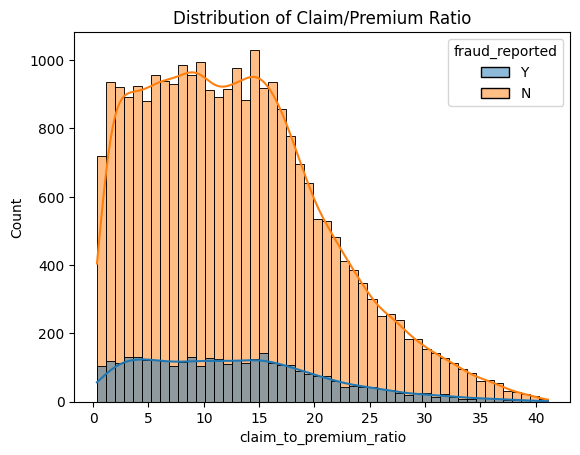

In [15]:
sns.histplot(data=df, x="claim_to_premium_ratio", hue="fraud_reported", bins=50, kde=True)
plt.title("Distribution of Claim/Premium Ratio")
plt.show()

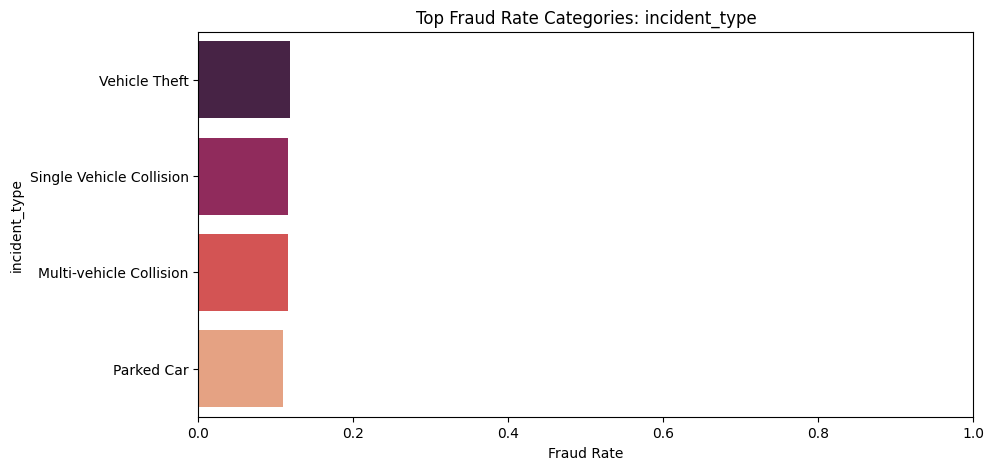

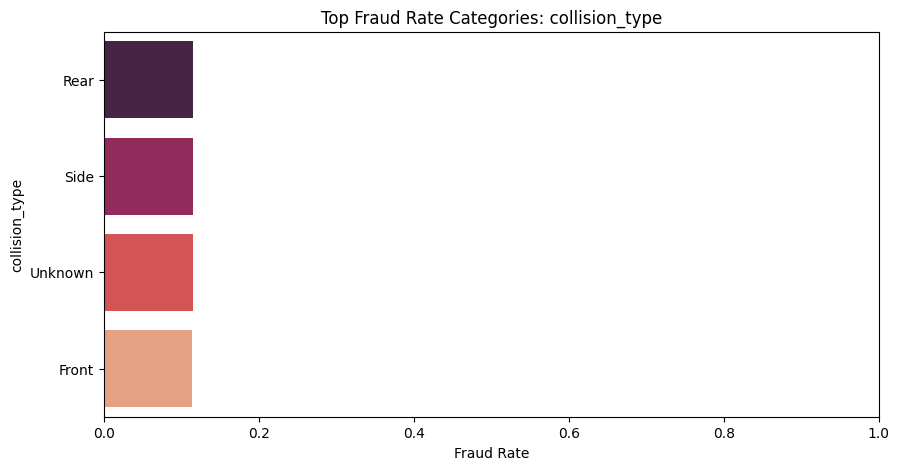

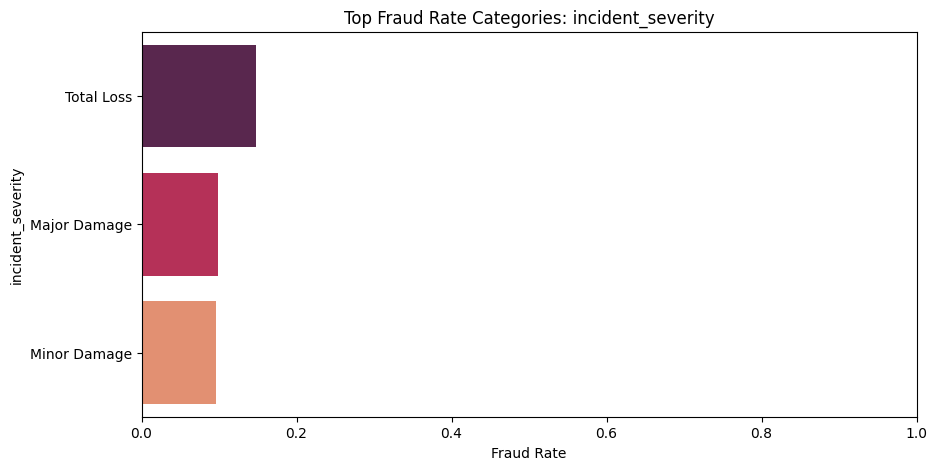

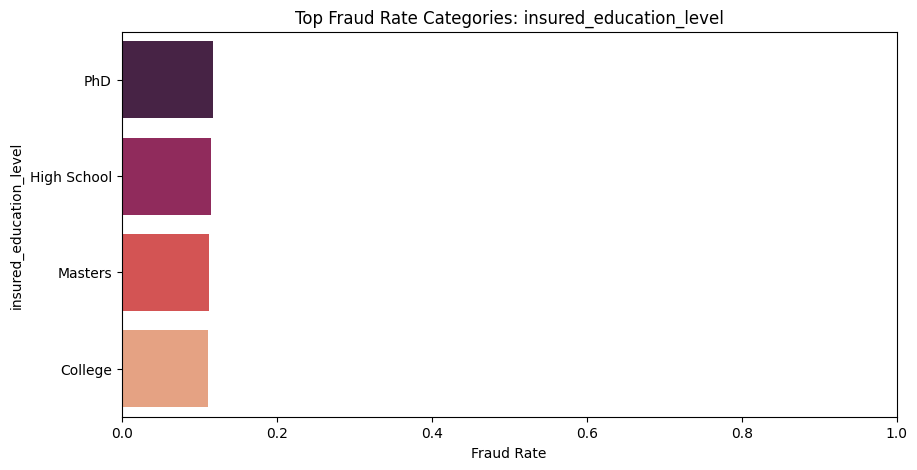

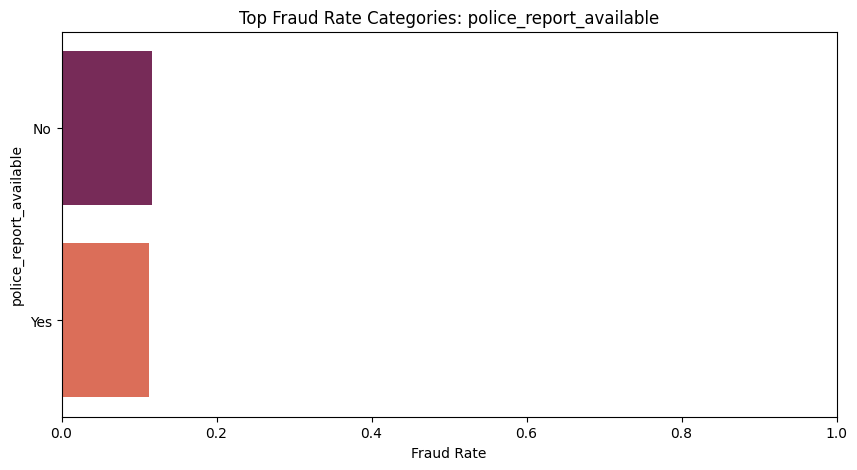

In [16]:
# Top risky categories by fraud rate
if "df_viz" not in globals():
    df_viz = df.copy()
    df_viz["fraud_flag"] = df_viz["fraud_reported"].map({"Y": 1, "N": 0}).astype("int8")

cat_cols = [
    "incident_type",
    "collision_type",
    "incident_severity",
    "insured_education_level",
    "police_report_available",
]

for c in cat_cols:
    if c in df_viz.columns:
        rate = df_viz.groupby(c)["fraud_flag"].mean().sort_values(ascending=False).head(10)

        plt.figure(figsize=(10, 5))
        sns.barplot(x=rate.values, y=rate.index, hue=rate.index, legend=False, palette="rocket")
        plt.title(f"Top Fraud Rate Categories: {c}")
        plt.xlabel("Fraud Rate")
        plt.ylabel(c)
        plt.xlim(0, 1)
        plt.show()

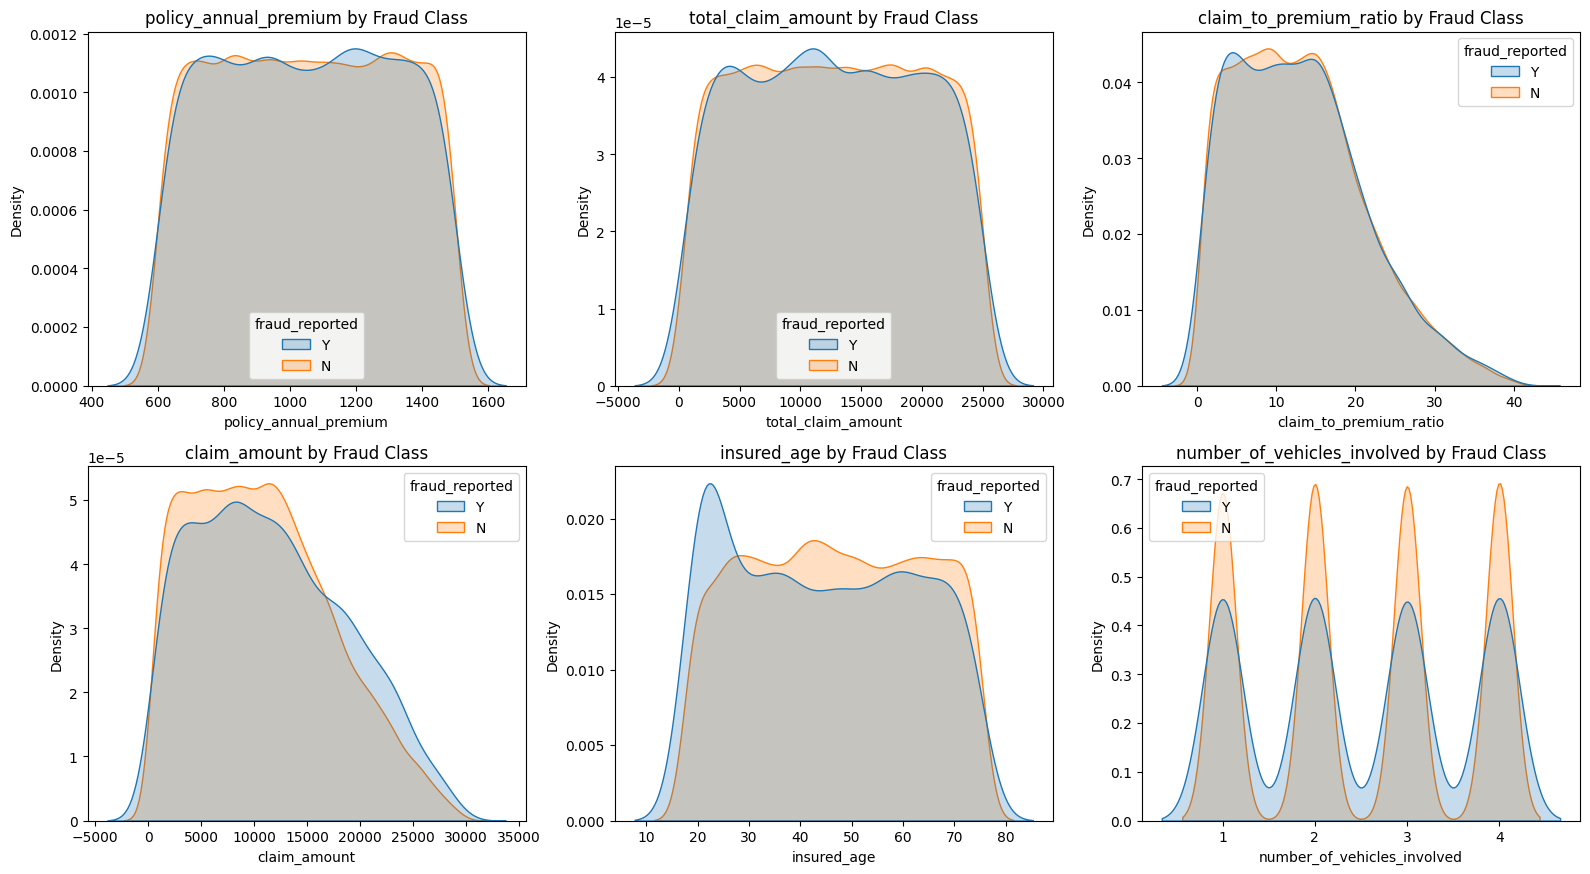

In [17]:
# Numeric behavior comparison by fraud class

if "df_viz" not in globals():
    df_viz = df.copy()

safe_premium = df_viz["policy_annual_premium"].replace(0, np.nan)
df_viz["claim_to_premium_ratio"] = (df_viz["total_claim_amount"] / safe_premium).fillna(0)

candidate_cols = [
    "policy_annual_premium",
    "total_claim_amount",
    "claim_to_premium_ratio",
    "claim_amount",
    "insured_age",
    "number_of_vehicles_involved",
]
num_cols = [c for c in candidate_cols if c in df_viz.columns]

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df_viz, x=col, hue="fraud_reported", fill=True, common_norm=False, ax=axes[i])
    axes[i].set_title(f"{col} by Fraud Class")

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\teffa\AppData\Local\Temp\ipykernel_28860\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_28860\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_28860\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_28860\1898630034.py:6: FutureWarning: 

Passing `palette` without

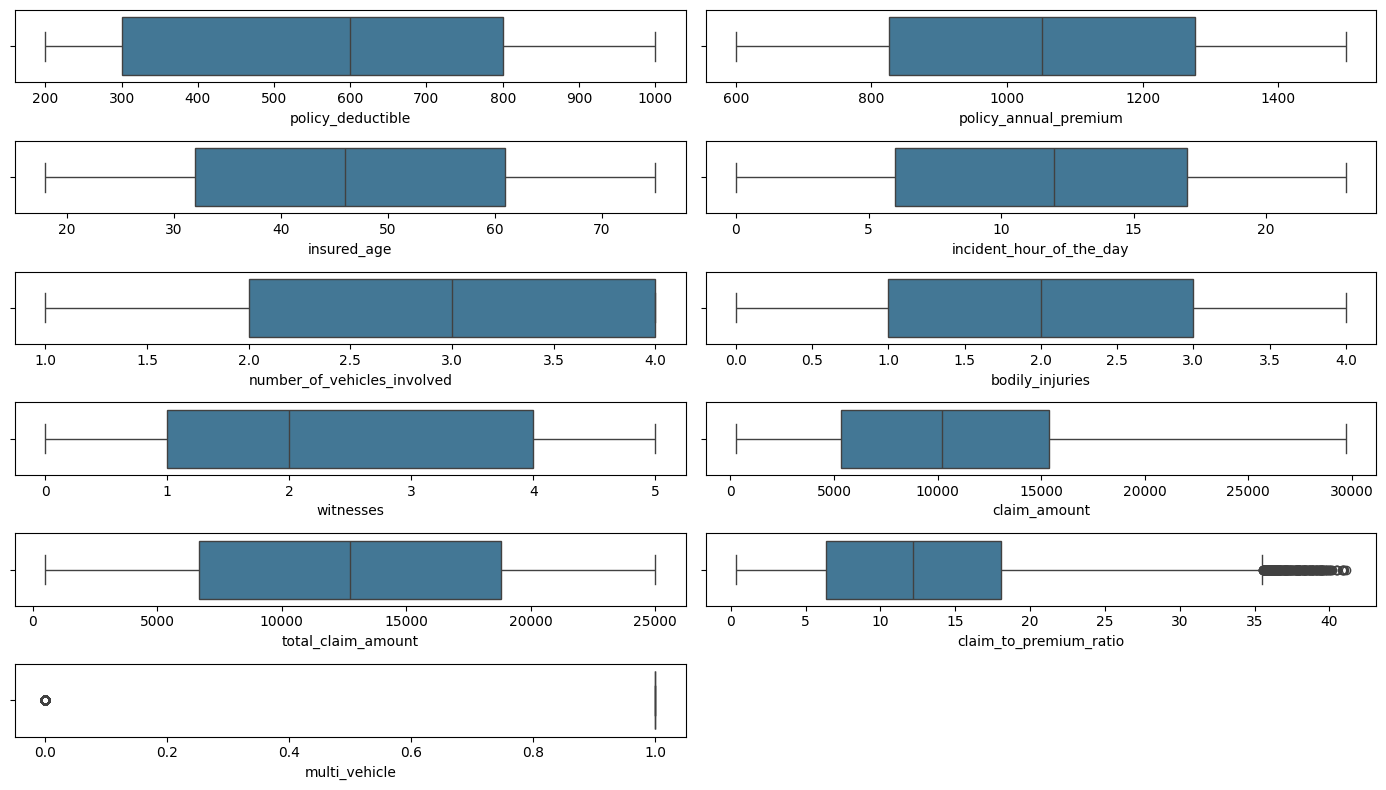

In [18]:
plt.figure(figsize=(14, 8))
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
for i, feature in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols)//2 + len(numerical_cols)%2, 2, i + 1)
    sns.boxplot(data=df,x=feature,palette='mako' 
    )
plt.tight_layout()
plt.show()

In [19]:
def cap_outliers_iqr(df, feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[feature] = df[feature].clip(lower, upper)

for feature in ["claim_to_premium_ratio"]:
    cap_outliers_iqr(df, feature)

C:\Users\teffa\AppData\Local\Temp\ipykernel_28860\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_28860\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_28860\1898630034.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=feature,palette='mako'
C:\Users\teffa\AppData\Local\Temp\ipykernel_28860\1898630034.py:6: FutureWarning: 

Passing `palette` without

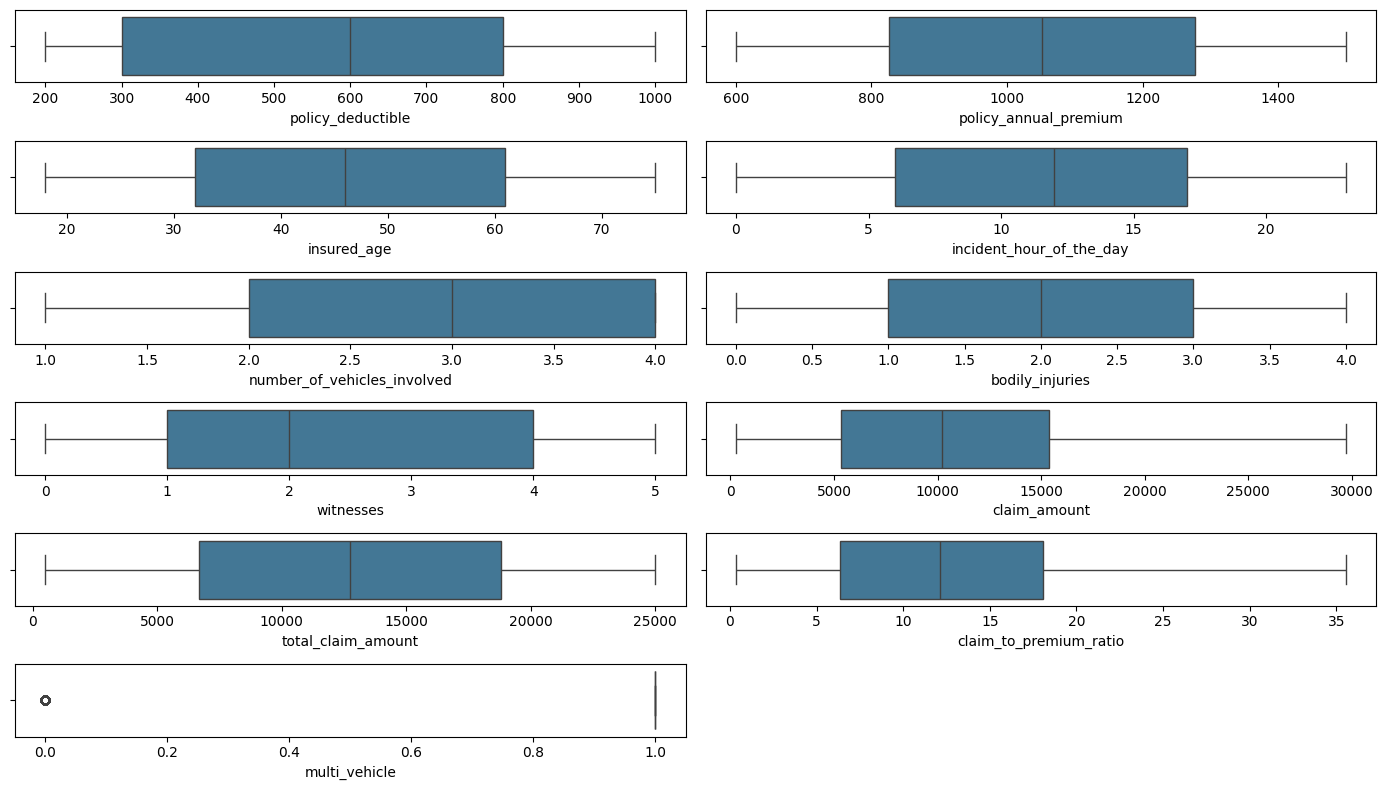

In [20]:
plt.figure(figsize=(14, 8))
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
for i, feature in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols)//2 + len(numerical_cols)%2, 2, i + 1)
    sns.boxplot(data=df,x=feature,palette='mako' 
    )
plt.tight_layout()
plt.show()

In [21]:
df.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,incident_type,collision_type,incident_severity,incident_state,...,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,claim_to_premium_ratio,multi_vehicle,claim_severity
0,GA,400,1430.78,74,OTHER,High School,Parked Car,Front,Total Loss,MI,...,1,4,0,Yes,8161.36,11677.60,Y,8.156002,0,1
1,PA,300,854.49,74,MALE,College,Vehicle Theft,Rear,Total Loss,OH,...,3,4,5,No,18561.79,18027.81,N,21.073081,1,2
2,MI,400,1247.28,28,OTHER,PhD,Parked Car,Unknown,Total Loss,MI,...,4,4,1,No,10734.61,10375.59,N,8.311909,1,1
3,CA,600,622.42,37,MALE,PhD,Parked Car,Rear,Total Loss,NC,...,3,3,5,No,13188.92,14204.34,N,22.784543,1,1
4,MI,700,1458.17,31,OTHER,PhD,Single Vehicle Collision,Side,Minor Damage,NY,...,4,2,4,No,21864.69,24038.84,N,16.474324,1,2


In [22]:
y = df["fraud_reported"]
X = df.drop("fraud_reported", axis=1)

In [23]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include=["object", "category", "bool"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

X[num_cols] = scaler.fit_transform(X[num_cols])

In [25]:
y = y.astype(str).str.strip().str.lower()

y = y.map({
    "y": 1,
    "yes": 1,
    "true": 1,
    "n": 0,
    "no": 0,
    "false": 0
})

In [26]:
df_final = X.copy()
df_final["fraud_reported"] = y

In [27]:
y.value_counts

<bound method IndexOpsMixin.value_counts of 0        1
1        0
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    0
29998    0
29999    0
Name: fraud_reported, Length: 30000, dtype: int64>

In [28]:
df_final["fraud_reported"].value_counts()

fraud_reported
0    26560
1     3440
Name: count, dtype: int64

In [29]:
from sklearn.model_selection import train_test_split

X = df_final.drop("fraud_reported", axis=1)
y = df_final["fraud_reported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=1.0
    ),

    "Naive Bayes": GaussianNB(),  # مفيهوش class_weight

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",   # مهم مع imbalance
        metric="minkowski"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=10,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    )
}





# 🚀 Training + Evaluation
results = {}

for name, model in models.items():
    print(f"\n🔹 {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


🔹 Logistic Regression
Accuracy: 0.5887
              precision    recall  f1-score   support

           0       0.92      0.59      0.72      5312
           1       0.16      0.59      0.25       688

    accuracy                           0.59      6000
   macro avg       0.54      0.59      0.48      6000
weighted avg       0.83      0.59      0.66      6000


🔹 Naive Bayes
Accuracy: 0.8853
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      5312
           1       0.00      0.00      0.00       688

    accuracy                           0.89      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.78      0.89      0.83      6000


🔹 KNN


d:\Ahmed\Ahmed\projects\Vehicle-Insurance-Fraud-Detection-End2End\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Ahmed\Ahmed\projects\Vehicle-Insurance-Fraud-Detection-End2End\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Ahmed\Ahmed\projects\Vehicle-Insurance-Fraud-Detection-End2End\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

Accuracy: 0.8830
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      5312
           1       0.23      0.01      0.02       688

    accuracy                           0.88      6000
   macro avg       0.56      0.50      0.48      6000
weighted avg       0.81      0.88      0.83      6000


🔹 Decision Tree
Accuracy: 0.6478
              precision    recall  f1-score   support

           0       0.92      0.66      0.77      5312
           1       0.17      0.55      0.26       688

    accuracy                           0.65      6000
   macro avg       0.55      0.60      0.52      6000
weighted avg       0.83      0.65      0.71      6000


🔹 Random Forest
Accuracy: 0.8507
              precision    recall  f1-score   support

           0       0.90      0.93      0.92      5312
           1       0.30      0.23      0.26       688

    accuracy                           0.85      6000
   macro avg       0.60      0.58      0.59

In [31]:
X_train.shape

(24000, 20)

In [32]:
def objective_lr(trial):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import recall_score, accuracy_score

    C = trial.suggest_float("C", 0.01, 10)
    threshold = trial.suggest_float("threshold", 0.3, 0.6)

    model = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:,1]
    y_pred = (y_probs > threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    score = 0.6 * recall + 0.4 * acc

    if acc < 0.6:
        score *= 0.5  
    return score

In [33]:
def objective_dt(trial):
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.metrics import recall_score, accuracy_score

    threshold = trial.suggest_float("threshold", 0.3, 0.6)

    model = DecisionTreeClassifier(
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:,1]
    y_pred = (y_probs > threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    score = 0.7 * recall + 0.3 * acc

    if acc < 0.6:
        score *= 0.7

    return score

In [34]:
def objective_rf(trial):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import recall_score, accuracy_score

    threshold = trial.suggest_float("threshold", 0.3, 0.6)

    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 150),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:,1]
    y_pred = (y_probs > threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    score = 0.7 * recall + 0.3 * acc

    if acc < 0.6:
        score *= 0.7

    return score

In [35]:
def objective_xgb(trial):
    from xgboost import XGBClassifier
    from sklearn.metrics import recall_score, accuracy_score

    threshold = trial.suggest_float("threshold", 0.3, 0.6)

    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 150),
        max_depth=trial.suggest_int("max_depth", 3, 6),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2),
        subsample=trial.suggest_float("subsample", 0.7, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
        gamma=trial.suggest_float("gamma", 0, 2),
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:,1]
    y_pred = (y_probs > threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    score = 0.7 * recall + 0.3 * acc

    if acc < 0.6:
        score *= 0.7

    return score

In [37]:
import optuna
import gc

studies = {}

objectives = {
    "Logistic": objective_lr,
    "DecisionTree": objective_dt,
    "RandomForest": objective_rf,
    "XGBoost": objective_xgb
    
}

for name, func in objectives.items():
    print(f"\n🔍 Tuning {name}")

    study = optuna.create_study(direction="maximize")
    study.optimize(func, n_trials=200, show_progress_bar=True)

    studies[name] = study

    print("Best Recall:", study.best_value)
    print("Best Params:", study.best_params)

    gc.collect()

[I 2026-04-05 20:19:09,097] A new study created in memory with name: no-name-f6a94062-5e3d-4aa9-a119-0c296ade7643



🔍 Tuning Logistic


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-04-05 20:19:09,138] Trial 0 finished with value: 0.3277255813953488 and parameters: {'C': 6.3771535234714305, 'threshold': 0.35280401801671957}. Best is trial 0 with value: 0.3277255813953488.
[I 2026-04-05 20:19:09,172] Trial 1 finished with value: 0.31943992248062014 and parameters: {'C': 0.8720341119192891, 'threshold': 0.42981838379109927}. Best is trial 0 with value: 0.3277255813953488.
[I 2026-04-05 20:19:09,210] Trial 2 finished with value: 0.3262391472868217 and parameters: {'C': 2.0752946876379985, 'threshold': 0.3424849424561857}. Best is trial 0 with value: 0.3277255813953488.
[I 2026-04-05 20:19:09,263] Trial 3 finished with value: 0.3252321705426357 and parameters: {'C': 0.6255926057381396, 'threshold': 0.3023429682895075}. Best is trial 0 with value: 0.3277255813953488.
[I 2026-04-05 20:19:09,293] Trial 4 finished with value: 0.3265031007751938 and parameters: {'C': 4.420515048813467, 'threshold': 0.3438961222681713}. Best is trial 0 with value: 0.3277255813953488

[I 2026-04-05 20:19:15,349] A new study created in memory with name: no-name-2c664816-86c9-4b42-b2ef-8f54ee8c9086


...

[I 2026-04-05 20:19:40,279] Trial 0 finished with value: 0.3551372093023256 and parameters: {'threshold': 0.45012145959183536, 'n_estimators': 105, 'max_depth': 14}. Best is trial 0 with value: 0.3551372093023256.
[I 2026-04-05 20:19:40,728] Trial 1 finished with value: 0.5055790697674418 and parameters: {'threshold': 0.3231395183896771, 'n_estimators': 123, 'max_depth': 10}. Best is trial 1 with value: 0.5055790697674418.
[I 2026-04-05 20:19:41,088] Trial 2 finished with value: 0.3742360465116279 and parameters: {'threshold': 0.4552717839670194, 'n_estimators': 91, 'max_depth': 13}. Best is trial 1 with value: 0.5055790697674418.
[I 2026-04-05 20:19:41,430] Trial 3 finished with value: 0.5098127906976744 and parameters: {'threshold': 0.3053925082038879, 'n_estimators': 76, 'max_depth': 14}. Best is trial 3 with value: 0.5098127906976744.
[I 2026-04-05 20:19:41,695] Trial 4 finished with value: 0.5591127906976744 and parameters: {'threshold': 0.447020838653859, 'n_estimators': 68, 'max

[I 2026-04-05 20:20:43,228] A new study created in memory with name: no-name-a1af99ba-af6e-483a-84af-c4844a4c265f


[I 2026-04-05 20:20:43,163] Trial 199 finished with value: 0.6068813953488372 and parameters: {'threshold': 0.44233339030780544, 'n_estimators': 70, 'max_depth': 7}. Best is trial 178 with value: 0.6307767441860466.
Best Recall: 0.6307767441860466
Best Params: {'threshold': 0.43541951603406753, 'n_estimators': 72, 'max_depth': 7}

🔍 Tuning XGBoost


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-04-05 20:20:43,359] Trial 0 finished with value: 0.5005463953488373 and parameters: {'threshold': 0.40675560044952874, 'n_estimators': 97, 'max_depth': 5, 'learning_rate': 0.014675724962487884, 'subsample': 0.9970429246771816, 'colsample_bytree': 0.7567446946435229, 'gamma': 1.6163562907433258}. Best is trial 0 with value: 0.5005463953488373.
[I 2026-04-05 20:20:43,439] Trial 1 finished with value: 0.47360930232558135 and parameters: {'threshold': 0.52957394685138, 'n_estimators': 80, 'max_depth': 3, 'learning_rate': 0.013826850195086336, 'subsample': 0.9284647556810004, 'colsample_bytree': 0.9416204347729016, 'gamma': 0.40154006449830515}. Best is trial 0 with value: 0.5005463953488373.
[I 2026-04-05 20:20:43,504] Trial 2 finished with value: 0.4859883720930232 and parameters: {'threshold': 0.5474084029663351, 'n_estimators': 54, 'max_depth': 5, 'learning_rate': 0.10818491658555945, 'subsample': 0.8622059358869847, 'colsample_bytree': 0.7483181407069078, 'gamma': 1.13021517389

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

final_models = {}

for name, study in studies.items():
    params = study.best_params.copy()
    threshold = params.pop("threshold")

    if name == "Logistic":
        model = LogisticRegression(
            **params,
            max_iter=1000,
            class_weight="balanced"
        )

    elif name == "DecisionTree":
        model = DecisionTreeClassifier(
            **params,
            class_weight="balanced",
            random_state=42
        )

    elif name == "RandomForest":
        model = RandomForestClassifier(
            **params,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        )

    elif name == "XGBoost":
        scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

        model = XGBClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        )


    model.fit(X_train, y_train)

    final_models[name] = {
        "model": model,
        "threshold": threshold
    }

In [39]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

for name, data in final_models.items():
    model = data["model"]
    threshold = data["threshold"]

    print(f"\n{'='*50}")
    print(f"🔹 Model: {name}")
    print(f"Best Threshold: {threshold:.3f}")
    print(f"{'='*50}")

    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs > threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    recc= recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Recall: {recc:.4f}")
    print("Confusion Matrix:")
    print(cm)


🔹 Model: Logistic
Best Threshold: 0.507
Accuracy: 0.6022
Recall: 0.5785
Confusion Matrix:
[[3215 2097]
 [ 290  398]]

🔹 Model: DecisionTree
Best Threshold: 0.414
Accuracy: 0.6390
Recall: 0.5828
Confusion Matrix:
[[3433 1879]
 [ 287  401]]

🔹 Model: RandomForest
Best Threshold: 0.435
Accuracy: 0.6002
Recall: 0.6439
Confusion Matrix:
[[3158 2154]
 [ 245  443]]

🔹 Model: XGBoost
Best Threshold: 0.455
Accuracy: 0.6017
Recall: 0.6846
Confusion Matrix:
[[3139 2173]
 [ 217  471]]


In [40]:
xgb_model = final_models["XGBoost"]["model"]
xgb_threshold = final_models["XGBoost"]["threshold"]

xgb_params = studies["XGBoost"].best_params.copy()
xgb_params.pop("threshold", None)

0.4553002080320843

In [41]:
import joblib

joblib.dump({
    "model": xgb_model,
    "threshold": xgb_threshold,
    "params": xgb_params,
    "features": X_train.columns.tolist()
}, "xgboost_full_pipeline.pkl")

['xgboost_full_pipeline.pkl']

In [42]:
data = joblib.load("xgboost_full_pipeline.pkl")

model = data["model"]
threshold = data["threshold"]
params = data["params"]
features = data["features"]

In [43]:
for k, v in params.items():
    print(f"{k}: {v}")

n_estimators: 77
max_depth: 3
learning_rate: 0.116957057378427
subsample: 0.9267967869058804
colsample_bytree: 0.9093970080917031
gamma: 0.9078466181417723


In [44]:
import joblib
from sklearn.metrics import classification_report

data = joblib.load("xgboost_full_pipeline.pkl")

model = data["model"]
threshold = data["threshold"]

y_probs = model.predict_proba(X_test)[:, 1]
y_pred = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.59      0.72      5312
           1       0.18      0.68      0.28       688

    accuracy                           0.60      6000
   macro avg       0.56      0.64      0.50      6000
weighted avg       0.85      0.60      0.67      6000

